Kevin Trujillo, 94079216@ifts24.edu.ar

Notebook.colab: https://colab.research.google.com/drive/148K9rUvFLdj9y9jh_mLkqUWUtA48Zueo?usp=sharing

Procedimiento, resultados y conclusiones: https://docs.google.com/document/d/1MBvlyk2L2G7-XGIxppcols2opQbPXWsIhLwrxfjaZF8/edit?usp=sharing

<hr>

# EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## DATASET - "MKT BANCO PORTUGAL"

Los datos están relacionados con campañas de marketing directo de una institución bancaria. Las campañas se basaron en llamadas telefónicas. A menudo, se requería más de un contacto con el mismo cliente para determinar si el producto (depósito a plazo bancario) sería (o no) suscrito.

El objetivo sera hacer un segmentación de clientes según caracteristicas similares para estrategias de marketing personalizado. Para por ejemplo: segmentar mis clientes para ver los diferentes grupos similares que tengo para ver si podria enfocarme en ofrecerles algun servicio especifico o más personalizado.


##Carga y exploración inicial del dataset

In [ ]:

#Conexion a mi Google Drive
from google.colab import drive
drive.mount('/content/drive')

#"traigo" el Dataset
bank = '/content/drive/MyDrive/TP - MINERIA DE DATOS/bank2.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerias a usar
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples

# leo el dataset, separo sus varibles "sep" y lo adjudico a mkt
mkt = pd.read_csv(bank, sep=';')


In [ ]:
#doy un vistazo general a la base
mkt

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


Observo las diferentes variables con las que vamos a trabajar (columnas), sus tipos de datos a priori y la cantidad de filas que tiene.

### Shape y Types


Utilizar el método shape nos da un preview del tamaño del dataset(aunque ya lo pudimos visualizar anteriormente), mientras que el método dtypes nos permite entender con qué tipo de datos estamos lidiando:

In [ ]:
mkt.shape

(4521, 17)

In [ ]:
mkt.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


### Descripción general del conjunto de datos

Obtenemos una descripción general (datos estadisticos) de las variables númericas del conjunto de datos, utilizando la función describe de pandas:

In [ ]:
#obtengo los datos con dos decimales
mkt.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,1422.66,15.92,263.96,2.79,39.77,0.54
std,10.58,3009.64,8.25,259.86,3.11,100.12,1.69
min,19.00,-3313.00,1.00,4.00,1.00,-1.00,0.00
25%,33.00,69.00,9.00,104.00,1.00,-1.00,0.00
50%,39.00,444.00,16.00,185.00,2.00,-1.00,0.00
75%,49.00,1480.00,21.00,329.00,3.00,-1.00,0.00
max,87.00,71188.00,31.00,3025.00,50.00,871.00,25.00


In [ ]:
mkt.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.17,10.58,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.66,3009.64,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.92,8.25,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.96,259.86,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.79,3.11,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.77,100.12,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.54,1.69,0.0,0.0,0.0,0.0,25.0


Esto nos dará algunas estadísticas básicas sobre las variables numéricas en el conjunto de datos, como el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los percentiles.

### Información del dataset:

Número de Instancias: 4521
Número de Atributos: 16 + atributo de salida.


Variables de entrada:

Datos del cliente bancario:
1 - age/edad (numérico)
2 - job/trabajo: tipo de trabajo (categórico: "administrativo", "desconocido", "desempleado", "dirección", "ama de casa", "emprendedor", "estudiante", "obrero", "autónomo", "jubilado", "técnico", "servicios")
3 - marital/estado civil: estado civil (categórico: "casado", "divorciado", "soltero"; nota: "divorciado" incluye divorciado o viudo)
4 - education/educación (categórico: "desconocido", "secundaria", "primaria", "superior")
5 - default/crédito: ¿tiene crédito en mora? (binario: "sí", "no")
6 - balance/saldo: saldo promedio anual, en euros (numérico)
7 - housing/vivienda: ¿tiene préstamo hipotecario? (binario: "sí", "no")
8 - loan/préstamo: ¿tiene préstamo personal? (binario: "sí", "no")

Relacionado con el último contacto de la campaña actual:
9 - contact/contacto: tipo de comunicación de contacto (categórico: "desconocido", "teléfono", "móvil")
10 - day/día: último día de contacto del mes (numérico)
11 - month/mes: último mes de contacto del año (categórico: "ene", "feb", "mar", ..., "nov", "dic")
12 - duration/duración: duración del último contacto en segundos (numérico)

Otros atributos:
13 - campaign/campaña: número de contactos realizados durante esta campaña y para este cliente (numérico, incluye el último contacto)
14 - pdays: número de días que pasaron después de que el cliente fue contactado por última vez en una campaña anterior (numérico, -1 significa que el cliente no fue contactado previamente)
15 - previous/previo: número de contactos realizados antes de esta campaña y para este cliente (numérico)
16 - poutcome/resultado: resultado de la campaña de marketing anterior (categórico: "desconocido", "otro", "fallo", "éxito")

Variable de salida (objetivo deseado):


17 - y - ¿ha suscrito el cliente un depósito a plazo? (binario: "sí", "no")

<hr>

Como nuestro objetivo es una segmentación y no una predicción, eliminaré algunas variables que considero por su falta de importancia al objetivo. Espero mi subjetividad y conocimientos de marketing esten en lo correcto.

In [ ]:
df = mkt.drop(['contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'y','poutcome'], axis=1)

¿Por qué esas variables?

Porque son resultados de campañas de marketing anteriores, es decir que no son caracteristicas intrinsecas del cliente, es especifico a un tipo de comportamiento con otro obejtivo. Por lo tanto decido quedarme con aspectos demograficos y financieros.

##Datos nulos y no númericos


In [ ]:
#con esta función puedo corroborar a ojo si los todas las columnas contienen datos, ya que coincide su total con el total general.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
dtypes: int64(2), object(6)
memory usage: 282.7+ KB


Esto nos dará información sobre el número de valores no nulos en cada columna y el tipo de datos de cada columna.

In [ ]:
#con esta función vemos explicitamente si existen valores nulos en alguna variable
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0


Convierto a mis variables categoricas a númericas, para que puedan ser funcionales a nuestro modelo K means.

In [ ]:
# One-Hot Encoding para variables sin orden (crea nuevas columnas/dimensiones, con lo cual este caso no seria "tan" adecuado para K means)
job_encoded = pd.get_dummies(df['job'], prefix='job')
marital_encoded = pd.get_dummies(df['marital'], prefix='marital')

# Ordinal Encoding para educación, ya que si hay "jerarquias" - 0,1,2
education_map = { 'unknown': 0,'primary': 1, 'secondary': 2, 'tertiary': 3}
df['education_encoded'] = df['education'].map(education_map)

# Binarias simples 0/1
df['default_binary'] = (df['default'] == 'yes').astype(int)
df['housing_binary'] = (df['housing'] == 'yes').astype(int)
df['loan_binary'] = (df['loan'] == 'yes').astype(int)

#concateno mis nuevas variables en un nuevo dataframe
df_num = pd.concat([
    df[['age', 'balance', 'education_encoded', 'default_binary', 'housing_binary', 'loan_binary']], job_encoded, marital_encoded], axis=1)

In [ ]:
df_num

,age,balance,education_encoded,default_binary,housing_binary,loan_binary,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single
0,30,1787,1,0,0,0,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,33,4789,2,0,1,1,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,35,1350,3,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,30,1476,3,0,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,59,0,2,0,1,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,-333,2,0,1,0,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4517,57,-3313,3,1,1,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4518,57,295,2,0,0,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4519,28,1137,2,0,0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


## Visualización de datos

La visualización de datos es una parte importante del EDA, ya que nos permite ver patrones y relaciones que podrían no ser evidentes en una tabla de datos. Además de darnos una vista general de la distribucion de los datos y su ruido.

## ANALISIS UNIVARIADO

### HISTOGRAMAS

In [ ]:
#Funcion para realizar histogramas a variables numericas
def plot_histograms(df):
    num_columns = df.select_dtypes(include='number').columns  # Selecciona solo las columnas numéricas

    # Generar un histograma para cada columna numérica
    for column in num_columns:

        # Calcular los límites del eje x usando el mínimo y máximo de cada columna (para mejor visualizacion)
        min_val = df[column].min()
        max_val = df[column].max()
        plt.xlim(min_val, max_val)  # Ajustar el rango del eje x al min y max


        plt.hist(df[column],bins=30, color='skyblue', edgecolor='black')
        plt.title(f'Histograma de {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.grid(True)
        plt.show()


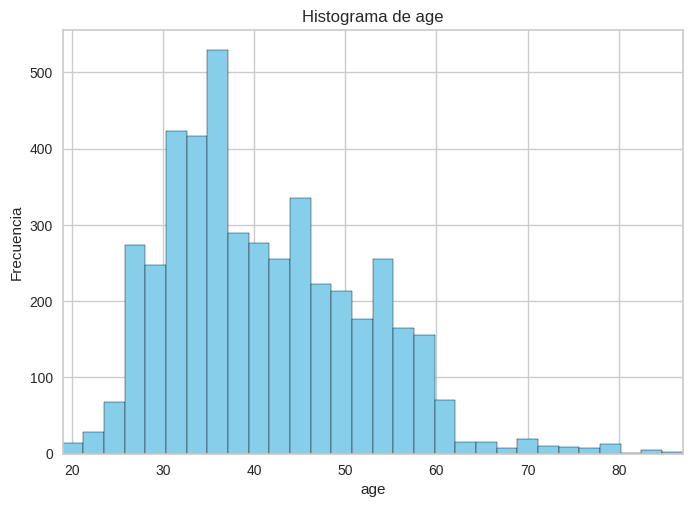

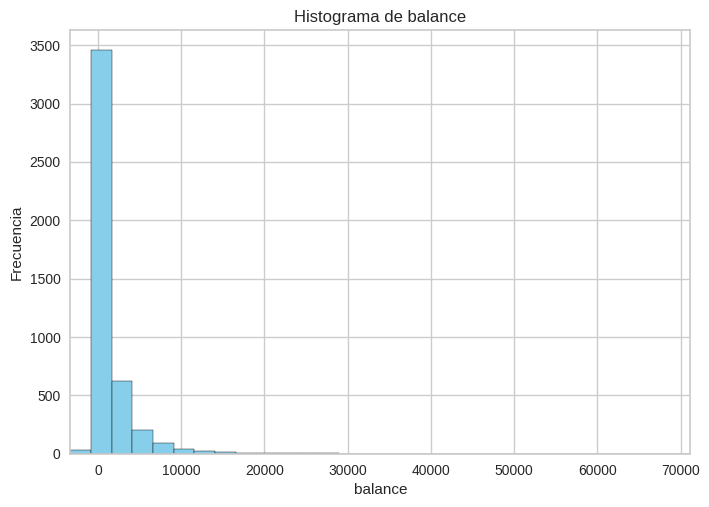

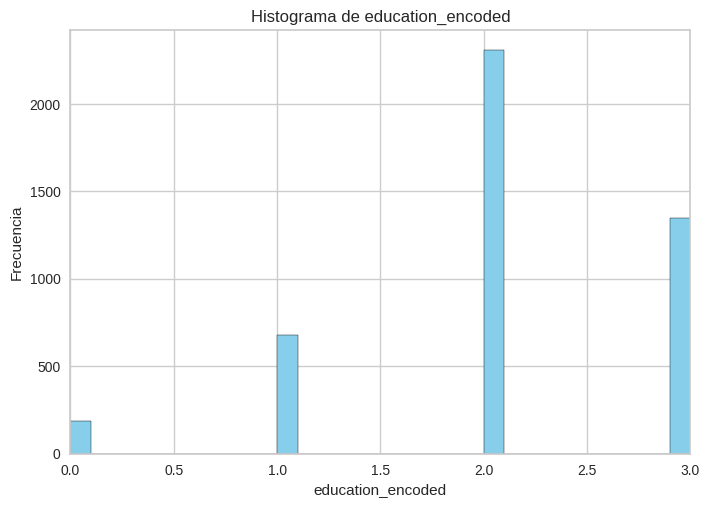

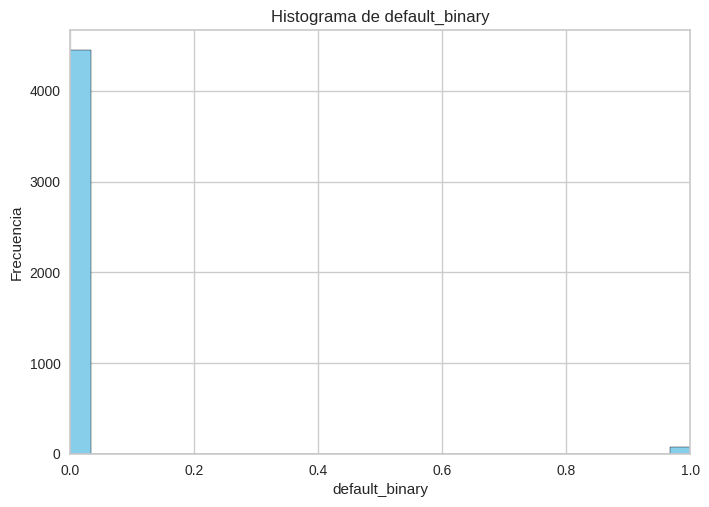

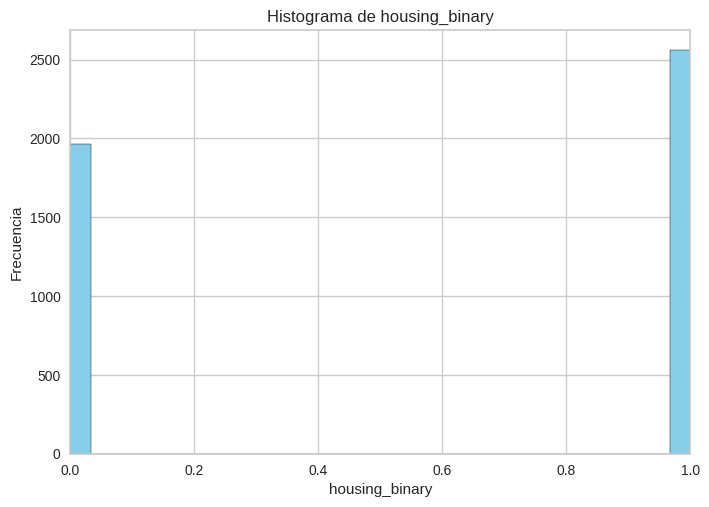

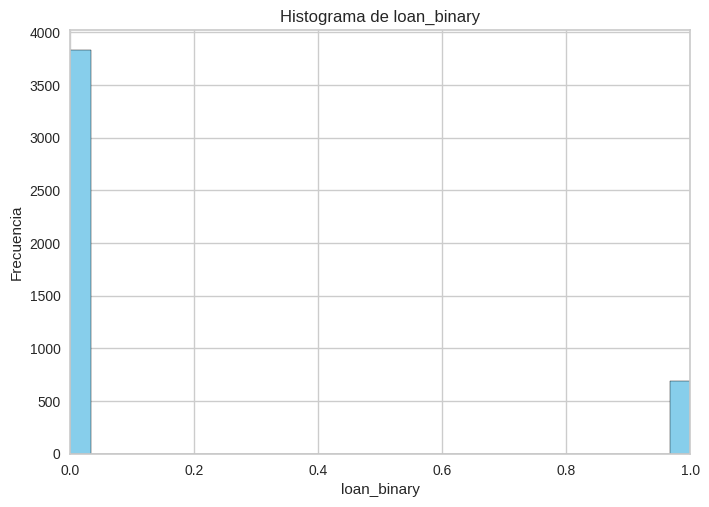

In [ ]:
#aplico la funcion creada anteriormente a mi dataset
plot_histograms(df_num)

### GRAFICO DE CAJAS Y BIGOTES

In [ ]:
#Funcion similar a la anterior, pero esta vez aplico grafico boxplot solo a variables que tienen lógica
def plot_box(df):
    box_columns = ['age', 'balance', 'education_encoded']

    for column in box_columns:
        plt.figure(figsize=(8, 6))

        # Boxplot vertical correcto
        sns.boxplot(y=df[column], color='skyblue')

        plt.title(f'Boxplot de {column}')
        plt.ylabel('Valores')
        plt.grid(True, alpha=0.3)
        plt.show()

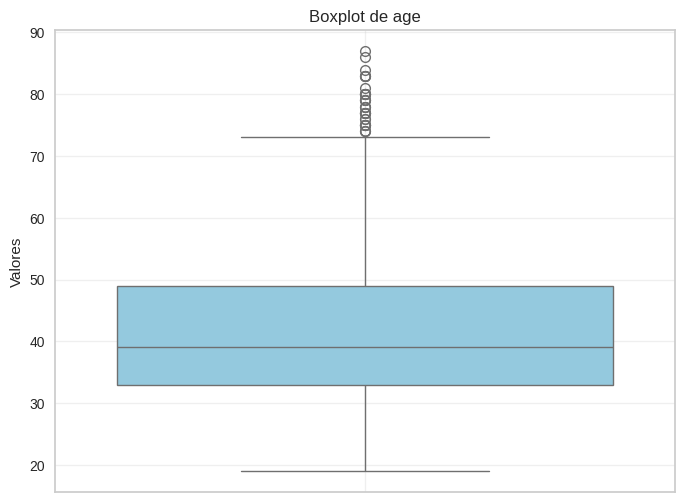

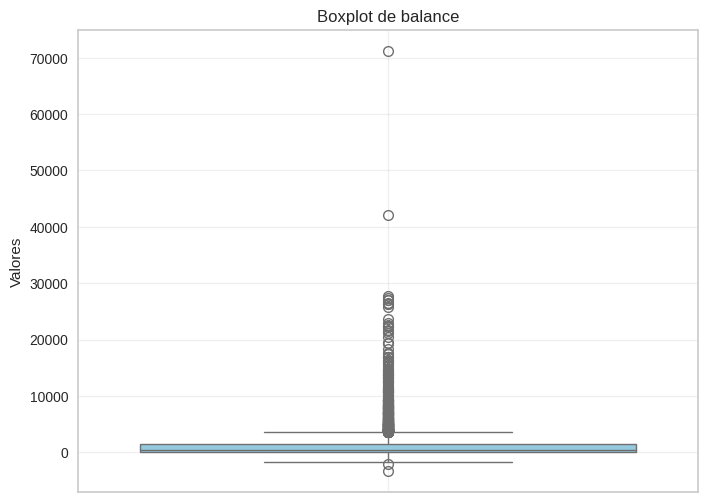

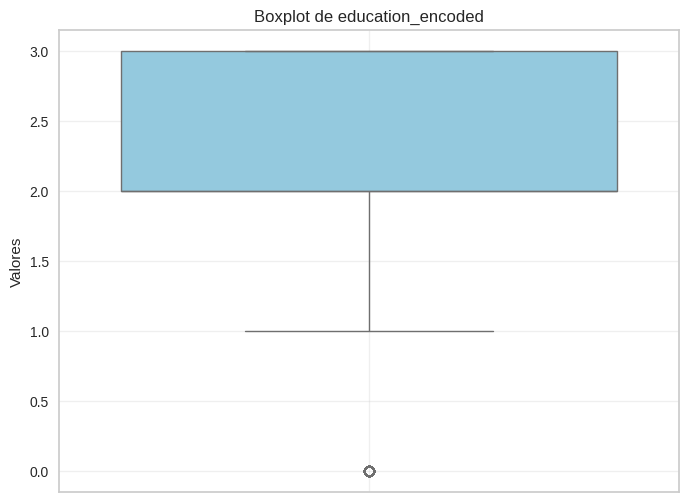

In [ ]:
plot_box(df_num)

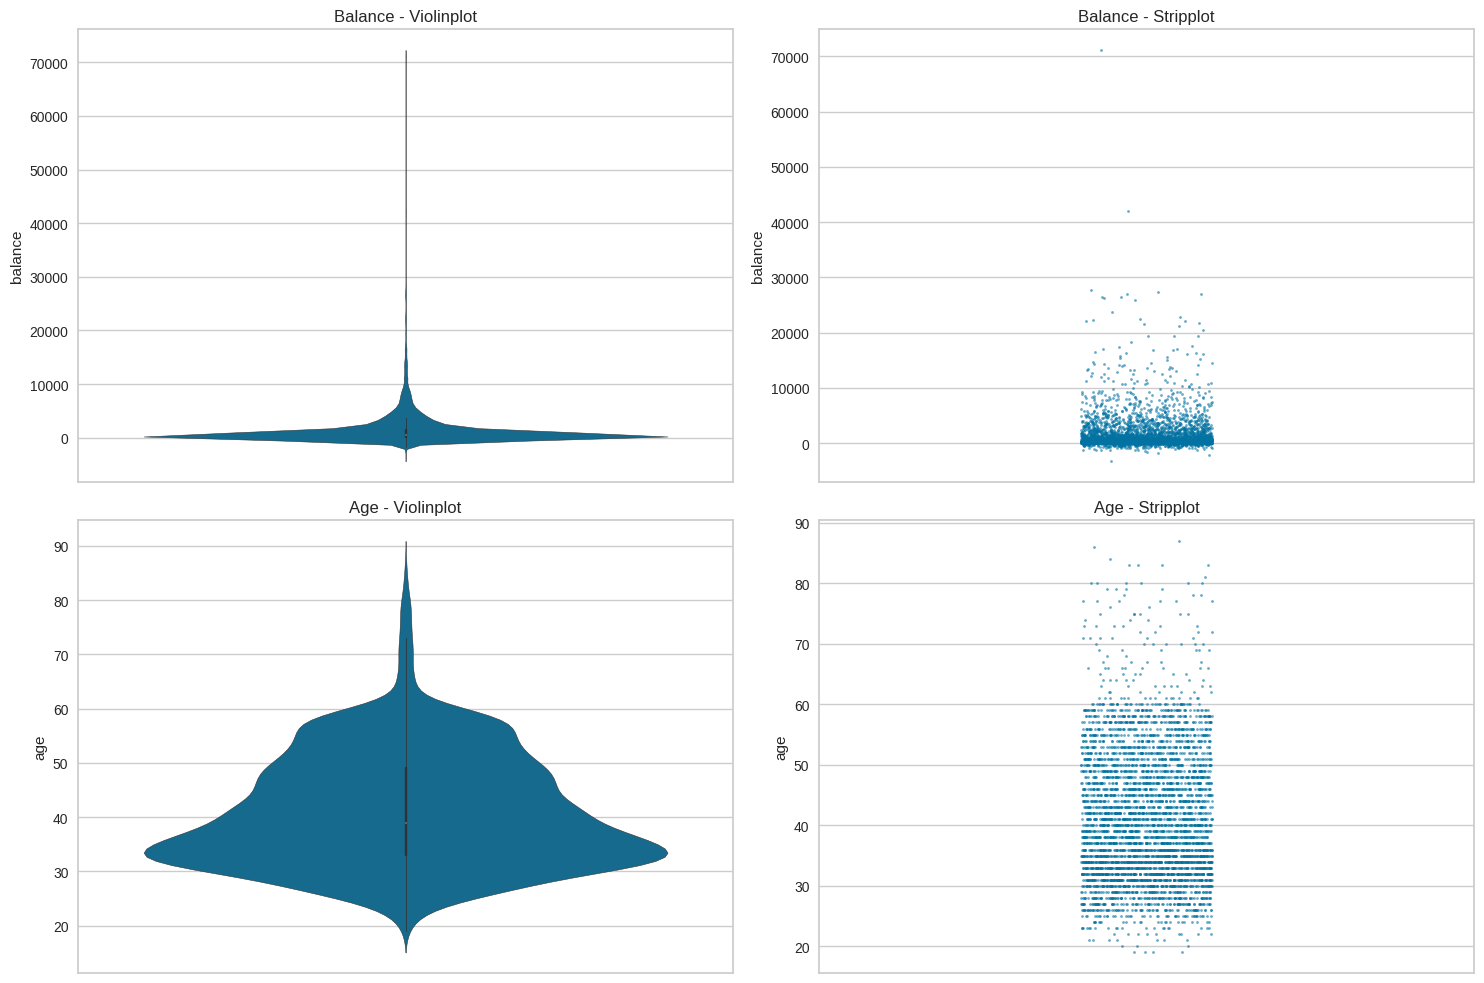

In [ ]:
# Creo una figura con 2 filas y 2 columnas de subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # figsize define el tamaño de la figura

# Subplot [0,0]: Violinplot para Balance
# El violinplot combina boxplot con distribución de densidad
sns.violinplot(y=df['balance'], ax=axes[0, 0])
axes[0, 0].set_title('Balance - Violinplot')  # Título del subplot

# Subplot [0,1]: Stripplot para Balance
# El stripplot muestra cada punto individualmente
sns.stripplot(y=df['balance'], ax=axes[0, 1], jitter=True, alpha=0.6, size=2)
axes[0, 1].set_title('Balance - Stripplot')
                    # jitter=True: agrega ruido aleatorio en el eje X para evitar superposición de puntos
                    # alpha: transparencia para ver puntos superpuestos
                    # size: tamaño pequeño de los puntos


# Subplot [1,0]: Violinplot para Age
sns.violinplot(y=df['age'], ax=axes[1, 0])
axes[1, 0].set_title('Age - Violinplot')

# Subplot [1,1]: Stripplot para Age
sns.stripplot(y=df['age'], ax=axes[1, 1], jitter=True, alpha=0.6, size=2)
axes[1, 1].set_title('Age - Stripplot')

plt.tight_layout() # Ajusta el espaciado entre subplots para evitar superposición

plt.show() # Muestra la figura

Se logra apreciar la existencia de datos atipicos, extremos en algunos casos, lo cual es perjudicial para nuestro algoritmo, ya que valores extremos arrastraran el centroide para su direccion, por lo tanto, se realizará un escalado para evitar la distorsion de los clusters.

#Aplicando Scaler

##StandarScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

df_st = df_num.copy() # copia para no modificar el original

# Aplico solo a variables numéricas continuas
scaler = StandardScaler()
df_st [['age', 'balance', 'education_encoded']] = scaler.fit_transform(
    df_st[['age', 'balance', 'education_encoded']])

# renombrar las columnas escaladas
df_st = df_st.rename(columns={
    'age': 'age_scaled',
    'balance': 'balance_scaled',
    'education_encoded': 'education_scaled'
})

In [ ]:
df_st

,age_scaled,balance_scaled,education_scaled,default_binary,housing_binary,loan_binary,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single
0,-1.056270,0.121072,-1.365123,0,0,0,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,-0.772583,1.118644,-0.084417,0,1,1,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,-0.583458,-0.024144,1.196289,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,-1.056270,0.017726,1.196289,0,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,1.686036,-0.472753,-0.084417,0,1,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,-0.772583,-0.583410,-0.084417,0,1,0,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4517,1.496912,-1.573671,1.196289,1,1,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4518,1.496912,-0.374724,-0.084417,0,0,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4519,-1.245394,-0.094925,-0.084417,0,0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


##RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler

df_Rob = df_num.copy()  # copia para no modificar el original

# Aplico la escala a mis datos
scaler = RobustScaler()
df_Rob[['age', 'balance', 'education_encoded']] = scaler.fit_transform(
    df_Rob[['age', 'balance', 'education_encoded']])

# renombrar las columnas escaladas
df_Rob = df_Rob.rename(columns={
    'age': 'age_scaled',
    'balance': 'balance_scaled',
    'education_encoded': 'education_scaled'
})

In [ ]:
df_Rob

,age_scaled,balance_scaled,education_scaled,default_binary,housing_binary,loan_binary,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single
0,-0.5625,0.951807,-1.0,0,0,0,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,-0.3750,3.079376,0.0,0,1,1,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,-0.2500,0.642098,1.0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,-0.5625,0.731396,1.0,0,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,1.2500,-0.314670,0.0,0,1,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,-0.3750,-0.550673,0.0,0,1,0,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4517,1.1250,-2.662651,1.0,1,1,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4518,1.1250,-0.105599,0.0,0,0,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4519,-0.6875,0.491141,0.0,0,0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


# Utilizacion del metodo del codo de K-Means para seleccionar  cantidad optica de grupos.


##Version StandarScaler

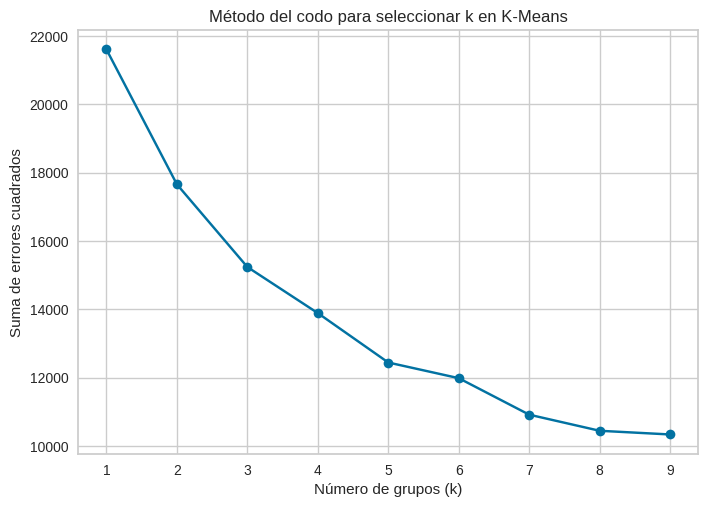

In [ ]:
from sklearn.cluster import KMeans
# Calcular la suma de errores cuadrados para diferentes valores de k
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_st)
    sse.append(kmeans.inertia_)

# Graficar la curva del codo
plt.plot(range(1, 10), sse, 'o-')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Suma de errores cuadrados')
plt.title('Método del codo para seleccionar k en K-Means')
plt.show()

No se logra apreciar el "quiebre" del K optimo, ya que pareciera que siempre disminuye de manera constante

K=2, Silhouette Score: 0.1971
K=3, Silhouette Score: 0.2052
K=4, Silhouette Score: 0.1504
K=5, Silhouette Score: 0.1666
K=6, Silhouette Score: 0.1692
K=7, Silhouette Score: 0.1633
K=8, Silhouette Score: 0.1566
K=9, Silhouette Score: 0.1429
K=10, Silhouette Score: 0.1442
K=11, Silhouette Score: 0.1423
K=12, Silhouette Score: 0.1607
K=13, Silhouette Score: 0.1514
K=14, Silhouette Score: 0.1538
K=15, Silhouette Score: 0.1464
K=16, Silhouette Score: 0.1491
K=17, Silhouette Score: 0.1534
K=18, Silhouette Score: 0.1529
K=19, Silhouette Score: 0.1580
K=20, Silhouette Score: 0.1629
K=21, Silhouette Score: 0.1599
K=22, Silhouette Score: 0.1591
K=23, Silhouette Score: 0.1648
K=24, Silhouette Score: 0.1694
K=25, Silhouette Score: 0.1742
K=26, Silhouette Score: 0.1802
K=27, Silhouette Score: 0.1812
K=28, Silhouette Score: 0.1848
K=29, Silhouette Score: 0.1877
K=30, Silhouette Score: 0.1906
K=31, Silhouette Score: 0.1993
K=32, Silhouette Score: 0.1985
K=33, Silhouette Score: 0.1991
K=34, Silhouette

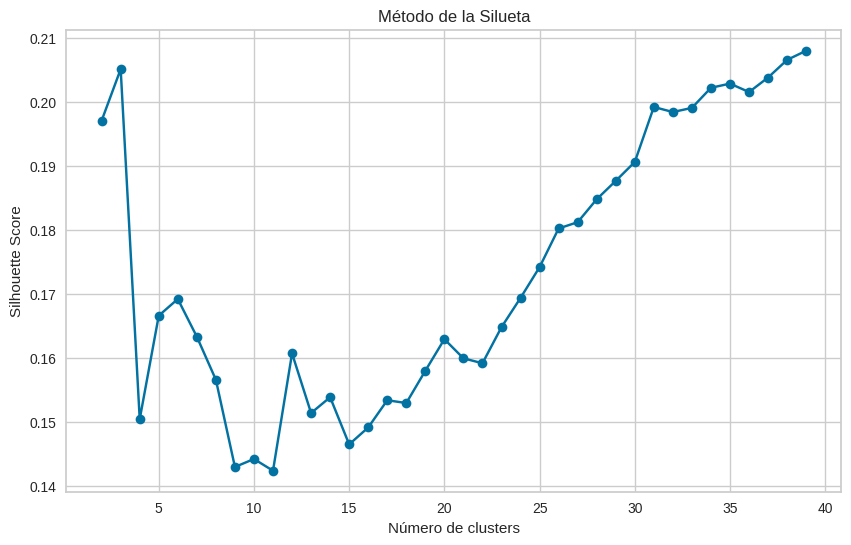

In [ ]:
from sklearn.metrics import silhouette_score

# Calcular scores de silueta para diferentes k
silhouette_scores = []
for k in range(2, 40):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_st)
    score = silhouette_score(df_st, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(range(2, 40), silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta')
plt.grid(True)
plt.show()

aumentando los k hipoteticos...si se logra apreciar el K optimo, que en este caso seria aproximadamente 3, lo cual se corrobora con el valor de la silueta más alto y eficiente, ya que despues de 38, hay mayor valor de la silueta, pero seria ineficiente, ya que es un valor muy alto.


Buscando el número óptimo de clústeres...


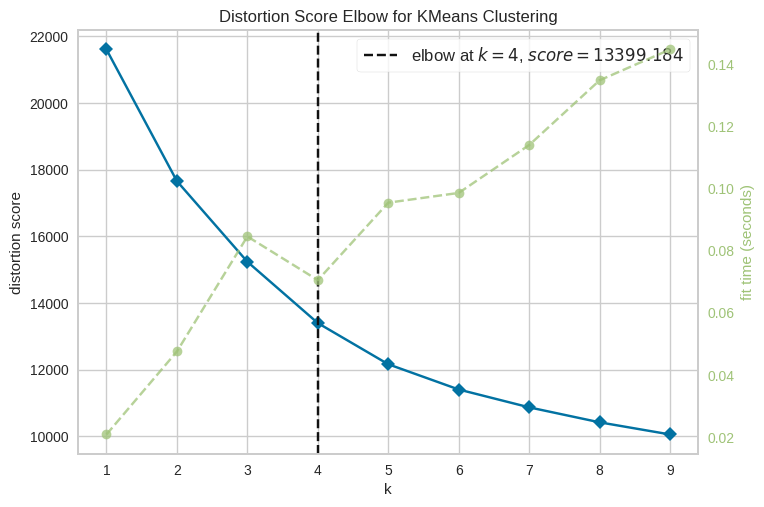

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 10))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_st)
visualizer.show()


Buscando el número óptimo de clústeres...


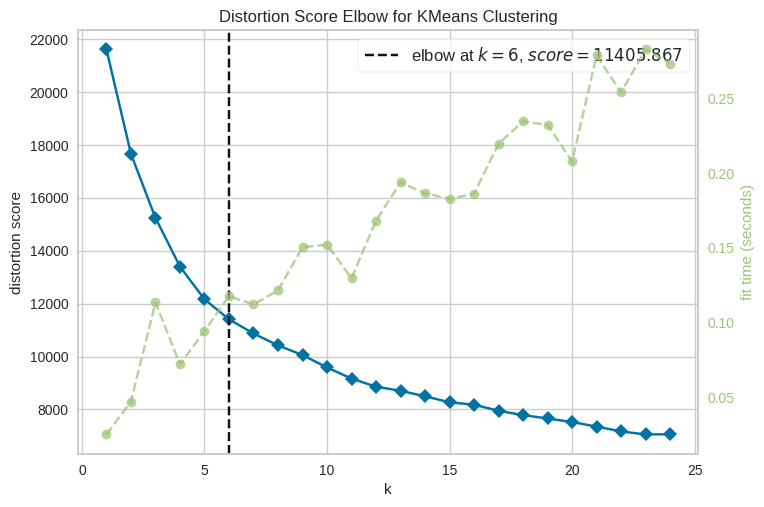

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 25))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_st)
visualizer.show()


Buscando el número óptimo de clústeres...


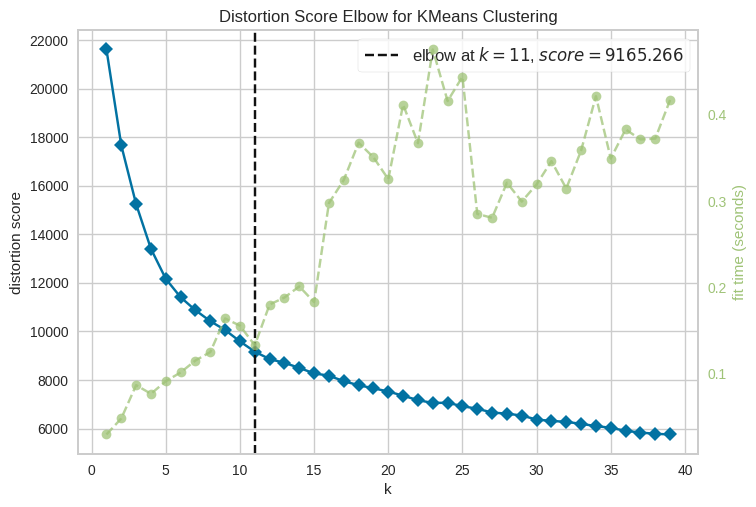

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 40))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_st)
visualizer.show()

A medida que se aumenta los posibles K, me entrega diferentes K optimos, siendo que esas "cantidades" ya estaban en casos anteriores.
¿A qué se debe? Consulte con Deep y su respuesta fue que se debia a:


1. El "codo" es subjetivo
Yellowbrick usa algoritmos automáticos para detectar el codo

Diferentes rangos = diferentes perspectivas de la curva

Lo que parece "óptimo" en un rango pequeño puede no serlo en uno más amplio

2. Métodos de detección automática
Yellowbrick puede usar diferentes métodos:

"distortion": Basado en inercia (SSE)

"silhouette": Basado en coeficiente de silueta

"calinski_harabasz": Basado en ratio de varianza

3. Se debe a mi bajo score de silueta, lo que quiere decir:

*K-Means no es el algoritmo ideal para estos datos

*Los clusters tienen mala separación natural

*Los datos pueden no tener estructura esférica clara

Interpretación del Método del Codo (Elbow Method)
k=(1, 10) te dio K=4: En este rango más pequeño, el algoritmo de detección del codo identificó una inflexión más pronunciada en K=4.
k=(1, 25) te dio K=6: Al ampliar el rango, la "visión" del algoritmo sobre la curva de inercia cambió. Es posible que el codo en K=4 se haya vuelto menos prominente en comparación con un codo más sutil en K=6 dentro de este rango extendido.
k=(1, 40) te dio K=11: Con un rango aún mayor, la curva de inercia se suaviza aún más, y el algoritmo encontró un punto de inflexión diferente, posiblemente más allá de los codos anteriores que eran más evidentes en rangos más pequeños.
Conclusión del Codo: Como discutimos, el método del codo es una heurística. Su resultado es subjetivo y altamente dependiente del rango explorado y de la sensibilidad del algoritmo de detección. No hay una "regla" definitiva, y la curva de inercia a menudo no tiene un codo perfectamente definido.

##Version RobustScaler

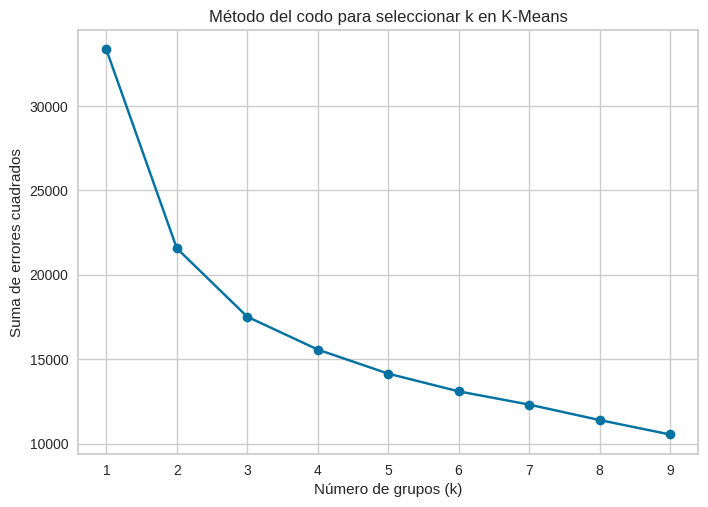

In [ ]:
from sklearn.cluster import KMeans
# Calcular la suma de errores cuadrados para diferentes valores de k
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_Rob)
    sse.append(kmeans.inertia_)

# Graficar la curva del codo
plt.plot(range(1, 10), sse, 'o-')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Suma de errores cuadrados')
plt.title('Método del codo para seleccionar k en K-Means')
plt.show()

No se logra apreciar el "quiebre" del K optimo, ya que pareciera que siempre disminuye de manera constante

K=2, Silhouette Score: 0.6387
K=3, Silhouette Score: 0.3891
K=4, Silhouette Score: 0.1651
K=5, Silhouette Score: 0.1663
K=6, Silhouette Score: 0.1683
K=7, Silhouette Score: 0.1551
K=8, Silhouette Score: 0.1435
K=9, Silhouette Score: 0.1565


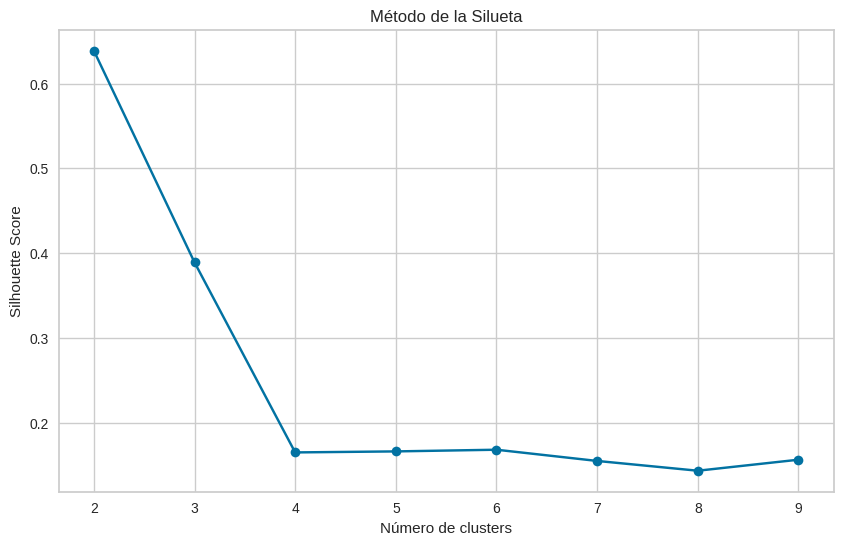

In [ ]:
from sklearn.metrics import silhouette_score

# Calcular scores de silueta para diferentes k
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_Rob)
    score = silhouette_score(df_Rob, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta')
plt.grid(True)
plt.show()

aumentando los k hipoteticos...si se logra apreciar el K optimo, que en este caso seria aproximadamente 3, lo cual se corrobora con el valor de la silueta más alto y eficiente, ya que despues de 38, hay mayor valor de la silueta, pero seria ineficiente, ya que es un valor muy alto.


Buscando el número óptimo de clústeres...


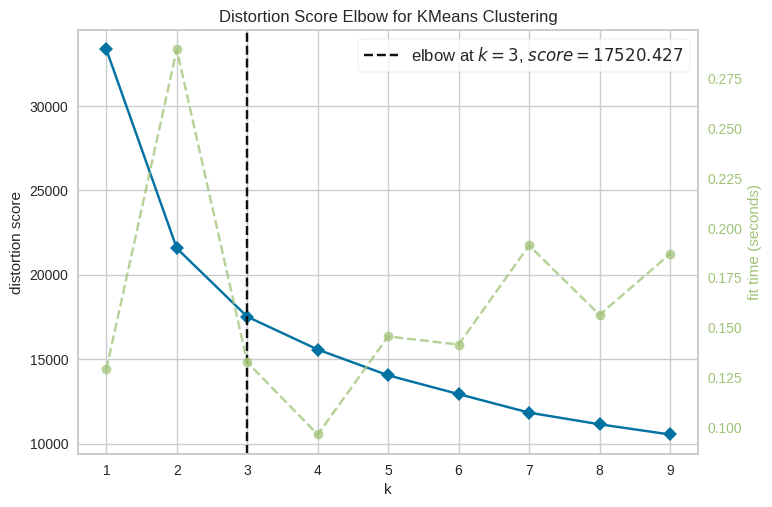

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 10))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_Rob)
visualizer.show()


Buscando el número óptimo de clústeres...


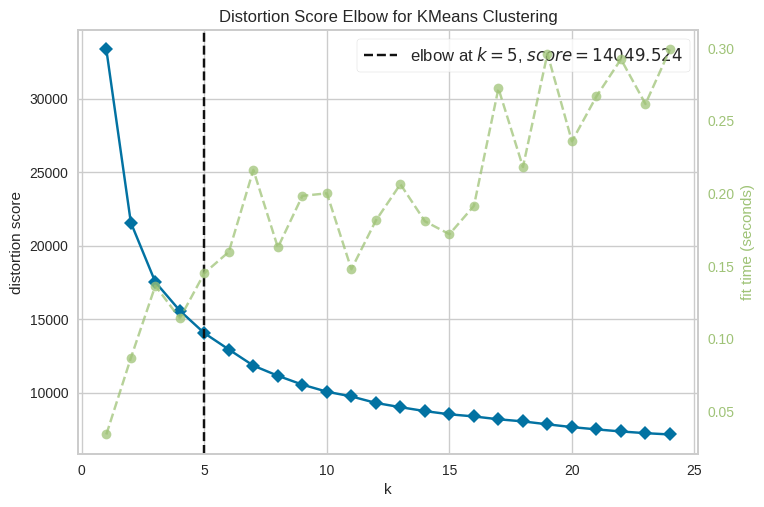

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 25))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_Rob)
visualizer.show()


Buscando el número óptimo de clústeres...


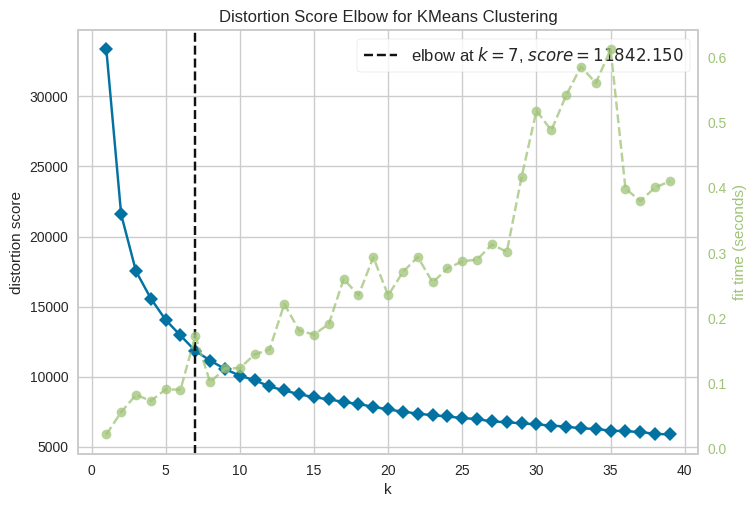

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Utiliza Yellowbrick para visualizar el método del codo
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 40))

print("\nBuscando el número óptimo de clústeres...")
visualizer.fit(df_Rob)
visualizer.show()

Vuelve a suceder lo mismo que en la Version de StandardScaler, aunque en este caso los K optimos que me entregan son más proximos entre si.

En este caso podemos apreciar que la silueta nos arroja buenos scores a diferencia de la version anterior y eso se debe a que la version original contenia Outliers, con lo cual era necesario realizarle un RobustScaler, en vez de Standar, ya que este si nos ayuda a reducir la influencia que tienen esos datos anomalos en nuestro modelo.

# Aplicar el Modelo K-Means con el K Óptimo

Obtuvimos un muy buen score en K = 2, lo cual indicaria que ese seria el óptimo....pero ¿Tiene sentido tener sólo dos grupos para segmentar tipos de cliente? Yo creo que son muy pocos...por lo tanto me gustaria quedarme con el K = 3 que si bien no supera el 0.50, igualmente es un buen número considerando que la metrica de la silueta va de -1 a 1.


Igualmente a modo de comparación haré el desarrollo de ambas K óptimas:

##K = 2

In [ ]:
# Se sugiere que el K óptimo es 2.
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Entrenar el modelo y asignar los clústeres a cada punto
y_kmeans = kmeans.fit_predict(df_Rob)
print("\nClústeres asignados a cada punto:")
print(y_kmeans)


Clústeres asignados a cada punto:
[1 1 1 ... 1 1 1]


### Analizar la Composición de los Grupos

In [ ]:
mkt0 = mkt.copy() # copia para no modificar el original y evitar errores de ejecuciones siguientes en k = 3

# Agregamos la columna de clústeres al DataFrame original (si no está ya)
if 'cluster' not in mkt0.columns:
    mkt0['cluster'] = y_kmeans

# Creamos una tabla de resumen con los promedios por clúster
cluster_summary = mkt0.groupby('cluster').agg(
    Cantidad_Clientes=('age', 'count'),  # Contar el número de clientes
    Edad_Promedio=('age', 'mean'),
    Balance_Promedio=('balance', 'mean'),
    Duracion_Promedio=('duration', 'mean'),
    Campañas_Promedio=('campaign', 'mean'),
    Contactos_Previos=('previous', 'mean')
).round(2)

# Creamos una fila para los promedios de la muestra total
total_summary_numerical = pd.DataFrame(mkt0[['age', 'balance', 'duration', 'campaign', 'previous']].mean()).T
total_summary_numerical.rename(columns={
    'age': 'Edad_Promedio',
    'balance': 'Balance_Promedio',
    'duration': 'Duracion_Promedio',
    'campaign': 'Campañas_Promedio',
    'previous': 'Contactos_Previos'
}, inplace=True)
total_summary_numerical['Cantidad_Clientes'] = len(mkt0)  # Agregamos el total de clientes
total_summary_numerical.index = ['Total']  # Nombramos el índice 'Total'

print("\nAnálisis comparativo de los Clústeres (variables numéricas):")
print(pd.concat([cluster_summary, total_summary_numerical], axis=0))

print("\n" + "="*60)

# Analizar la distribución de variables categóricas por clúster
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y']

for var in categorical_vars:
    print(f"\nDistribución de '{var}' por Clúster (%):")
    crosstab = pd.crosstab(mkt0['cluster'], mkt0[var], normalize='index') * 100
    total_distribution = mkt0[var].value_counts(normalize=True) * 100
    var_summary = pd.concat([crosstab, total_distribution.to_frame(name='Total').T])
    print(var_summary.round(1))

print("\n" + "="*60)



Análisis comparativo de los Clústeres (variables numéricas):
       Cantidad_Clientes  Edad_Promedio  Balance_Promedio  Duracion_Promedio  \
0                    232      43.820000      11202.910000         239.890000   
1                   4289      41.030000        893.630000         265.260000   
Total               4521      41.170095       1422.657819         263.961292   

       Campañas_Promedio  Contactos_Previos  
0                2.84000           0.730000  
1                2.79000           0.530000  
Total            2.79363           0.542579  


Distribución de 'job' por Clúster (%):
job    admin.  blue-collar  entrepreneur  housemaid  management  retired  \
0         5.2         12.9           4.3        4.7        32.8      8.6   
1        10.9         21.4           3.7        2.4        20.8      4.9   
Total    10.6         20.9           3.7        2.5        21.4      5.1   

job    self-employed  services  student  technician  unemployed  unknown  
0           

### Obtener coordendas de los centroides

In [ ]:
# Obtener los centroides del modelo K-Means
centroides_escalados = kmeans.cluster_centers_

# Extrae solo las 3 variables que escalamos
centroides_variables_escaladas = centroides_escalados[:, :3]  # age_scaled, balance_scaled, education_scaled

# Obtener los parámetros del RobustScaler (asumiendo que usaste el mismo para las 3 variables)

robust_scaler = RobustScaler()
robust_scaler.fit(df_num[['age', 'balance', 'education_encoded']])

# Transformar los centroides de vuelta a valores originales
centroides_originales = robust_scaler.inverse_transform(centroides_variables_escaladas)

# Crear DataFrame con los resultados
centroides_df = pd.DataFrame(
    centroides_originales,
    columns=['age', 'balance', 'education_encoded'],
    index=[f'Cluster {i}' for i in range(len(centroides_originales))]
)

print("Valores de los centroides finales (valores originales):")
print(centroides_df.round(2))

Valores de los centroides finales (valores originales):
             age   balance  education_encoded
Cluster 0  43.82  11202.91               2.20
Cluster 1  41.03    893.63               2.06


In [ ]:
#grafico iterativo
fig_corrected = go.Figure()

# Primero, necesitamos mapear education a education_encoded para la visualización
education_map = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 1.5}
mkt0['education_encoded_temp'] = mkt0['education'].map(education_map)

# Agregar puntos de datos por cluster usando education_encoded
colors = ['blue', 'green']
for cluster in sorted(mkt0['cluster'].unique()):
    cluster_data = mkt0[mkt0['cluster'] == cluster]
    fig_corrected.add_trace(go.Scatter3d(
        x=cluster_data['age'],
        y=cluster_data['balance'],
        z=cluster_data['education_encoded_temp'],  # Usar encoded, no original
        mode='markers',
        marker=dict(size=4, opacity=0.6, color=colors[cluster]),
        name=f'Cluster {cluster}',
        hovertemplate=
        '<b>Edad:</b> %{x}<br>' +
        '<b>Balance:</b> €%{y:,.0f}<br>' +
        '<b>Educación:</b> %{z}<br>' +
        '<extra></extra>'
    ))

# Agregar centroides (usando las mismas variables)
fig_corrected.add_trace(go.Scatter3d(
    x=centroides_df['age'],
    y=centroides_df['balance'],
    z=centroides_df['education_encoded'],  # Mismo que education_encoded_temp
    mode='markers+text',
    marker=dict(size=12, color='red', symbol='diamond'),
    text=[f'Centroide {i}' for i in range(len(centroides_df))],
    textposition='top center',
    name='Centroides',
    hovertemplate=
    '<b>Centroide</b><br>' +
    '<b>Edad:</b> %{x:.1f}<br>' +
    '<b>Balance:</b> €%{y:,.0f}<br>' +
    '<b>Educación:</b> %{z:.1f}<br>' +
    '<extra></extra>'
))

fig_corrected.update_layout(
    title='Segmentación de Clientes - Visualización 3D Corregida',
    scene=dict(
        xaxis_title='Edad',
        yaxis_title='Balance (€)',
        zaxis_title='Nivel Educativo (1=Primaria, 2=Secundaria, 3=Terciaria)'
    ),
    width=800,
    height=600
)

fig_corrected.show()

###Evaluación del modelo

In [ ]:

# “Qué tan similar es un punto a otros ubicados dentro de su cluster, respecto a otro punto perteneciente al cluster más cercano”
print("--- Evaluación del Modelo ---")
silhouette_avg = silhouette_score(df_Rob, y_kmeans)
print(f"Puntuación de la Silueta: {silhouette_avg:.4f}")

calinski_harabasz_avg = calinski_harabasz_score(df_Rob, y_kmeans)
print(f"Índice de Calinski-Harabasz: {calinski_harabasz_avg:.4f}")

davies_bouldin_avg = davies_bouldin_score(df_Rob, y_kmeans)
print(f"Índice de Davies-Bouldin: {davies_bouldin_avg:.4f}")

--- Evaluación del Modelo ---
Puntuación de la Silueta: 0.6387
Índice de Calinski-Harabasz: 2465.9854
Índice de Davies-Bouldin: 0.7562



Generando el gráfico de Silueta...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



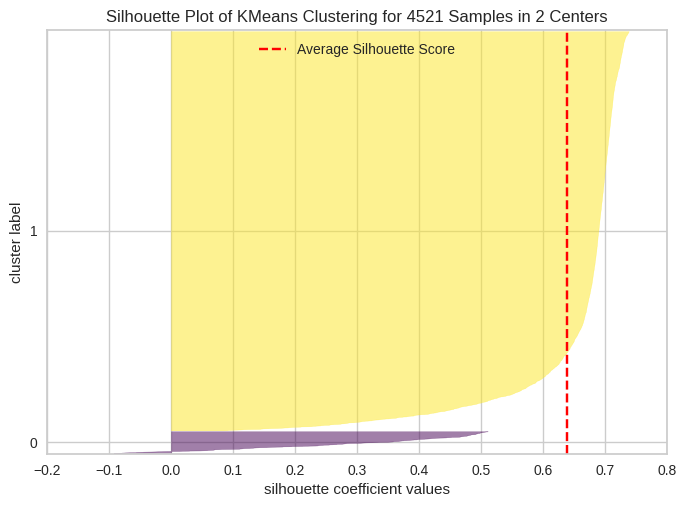

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4521 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# ----------------------------------------------------
# Visualizar la Puntuación de la Silueta
# ----------------------------------------------------


print("\nGenerando el gráfico de Silueta...")

# Crea el visualizador de silueta
visualizer = SilhouetteVisualizer(kmeans, colors='viridis')

visualizer.fit(df_Rob)    # Entrena el visualizador con los datos escalados
visualizer.show()       # Muestra el gráfico

In [ ]:

# Obtener la puntuación de silueta para cada punto individual
sample_silhouette_values = silhouette_samples(df_Rob, y_kmeans)

# Puntuación de la silueta promedio para todo el dataset
average_silhouette_score = silhouette_score(df_Rob, y_kmeans)

# Contar cuántos puntos están por debajo, igual o por encima del promedio
below_average = (sample_silhouette_values < average_silhouette_score).sum()
equal_average = (sample_silhouette_values == average_silhouette_score).sum()
above_average = (sample_silhouette_values > average_silhouette_score).sum()

total_samples = len(df_Rob)

print("\n--- Análisis de la distribución de la Silueta ---")
print(f"Puntuación promedio de la Silueta: {average_silhouette_score:.4f}")
print("-" * 50)
print(f"Puntos por debajo del promedio: {below_average} ({below_average/total_samples*100:.2f}%)")
print(f"Puntos igual al promedio: {equal_average} ({equal_average/total_samples*100:.2f}%)")
print(f"Puntos por encima del promedio: {above_average} ({above_average/total_samples*100:.2f}%)")

# Obtener la puntuación de silueta para cada punto individual
sample_silhouette_values = silhouette_samples(df_Rob, y_kmeans)

# Puntuación de la silueta promedio para todo el dataset
average_silhouette_score = silhouette_score(df_Rob, y_kmeans)

# Agregar las puntuaciones de silueta individuales al DataFrame
mkt0['silhouette_score'] = sample_silhouette_values

#print("\n--- Análisis de la distribución de la Silueta por Clúster ---")
#print(f"Puntuación promedio de la Silueta para toda la muestra: {average_silhouette_score:.4f}")
#print("-" * 70)

# Agrupar por clúster y calcular estadísticas descriptivas
silhouette_summary = mkt0.groupby('cluster')['silhouette_score'].agg(['mean', 'min', 'max'])
print(silhouette_summary)

print("-" * 70)

# Crear una tabla de contingencia para la distribución de silueta
# Asignamos una etiqueta a cada punto: 'Por debajo', 'Igual' o 'Por encima'
mkt0['silhouette_category'] = pd.cut(mkt0['silhouette_score'],
                                   bins=[-1, average_silhouette_score, 1],
                                   labels=['Por Debajo o Igual', 'Por Encima'])

# Analizar la distribución de categorías por clúster
cluster_distribution = pd.crosstab(mkt0['cluster'], mkt0['silhouette_category'], normalize='index') * 100

print("Distribución de la Puntuación de Silueta por Clúster (%):")
print(cluster_distribution)


--- Análisis de la distribución de la Silueta ---
Puntuación promedio de la Silueta: 0.6387
--------------------------------------------------
Puntos por debajo del promedio: 1073 (23.73%)
Puntos igual al promedio: 0 (0.00%)
Puntos por encima del promedio: 3448 (76.27%)
             mean       min       max
cluster                              
0        0.290597 -0.092656  0.510675
1        0.657548  0.084701  0.738162
----------------------------------------------------------------------
Distribución de la Puntuación de Silueta por Clúster (%):
silhouette_category  Por Debajo o Igual  Por Encima
cluster                                            
0                              100.0000      0.0000
1                               19.6083     80.3917


##K = 3

In [ ]:
# Se sugiere que el K óptimo es 3.
kmeans3 = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Entrenar el modelo y asignar los clústeres a cada punto
y_kmeans3 = kmeans3.fit_predict(df_Rob)
print("\nClústeres asignados a cada punto:")
print(y_kmeans3)


Clústeres asignados a cada punto:
[1 0 1 ... 1 1 1]


### Analizar la Composición de los Grupos

In [ ]:
mkt1 = mkt.copy()
# Agregamos la columna de clústeres al DataFrame original (si no está ya)
if 'cluster' not in mkt1.columns:
    mkt1['cluster'] = y_kmeans3

# Creamos una tabla de resumen con los promedios por clúster
cluster_summary = mkt1.groupby('cluster').agg(
    Cantidad_Clientes=('age', 'count'),  # Contar el número de clientes
    Edad_Promedio=('age', 'mean'),
    Balance_Promedio=('balance', 'mean'),
    Duracion_Promedio=('duration', 'mean'),
    Campañas_Promedio=('campaign', 'mean'),
    Contactos_Previos=('previous', 'mean')
).round(2)

# Creamos una fila para los promedios de la muestra total
total_summary_numerical = pd.DataFrame(mkt1[['age', 'balance', 'duration', 'campaign', 'previous']].mean()).T
total_summary_numerical.rename(columns={
    'age': 'Edad_Promedio',
    'balance': 'Balance_Promedio',
    'duration': 'Duracion_Promedio',
    'campaign': 'Campañas_Promedio',
    'previous': 'Contactos_Previos'
}, inplace=True)
total_summary_numerical['Cantidad_Clientes'] = len(mkt1)  # Agregamos el total de clientes
total_summary_numerical.index = ['Total']  # Nombramos el índice 'Total'

print("\nAnálisis comparativo de los Clústeres (variables numéricas):")
print(pd.concat([cluster_summary, total_summary_numerical], axis=0))

print("\n" + "="*60)

# Analizar la distribución de variables categóricas por clúster
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y']

for var in categorical_vars:
    print(f"\nDistribución de '{var}' por Clúster (%):")
    crosstab = pd.crosstab(mkt1['cluster'], mkt1[var], normalize='index') * 100
    total_distribution = mkt1[var].value_counts(normalize=True) * 100
    var_summary = pd.concat([crosstab, total_distribution.to_frame(name='Total').T])
    print(var_summary.round(1))

print("\n" + "="*60)



Análisis comparativo de los Clústeres (variables numéricas):
       Cantidad_Clientes  Edad_Promedio  Balance_Promedio  Duracion_Promedio  \
0                    589      43.190000       5186.030000         273.870000   
1                   3862      40.800000        541.670000         263.590000   
2                     70      44.540000      18361.770000         200.930000   
Total               4521      41.170095       1422.657819         263.961292   

       Campañas_Promedio  Contactos_Previos  
0                2.74000           0.590000  
1                2.80000           0.530000  
2                3.01000           0.760000  
Total            2.79363           0.542579  


Distribución de 'job' por Clúster (%):
job    admin.  blue-collar  entrepreneur  housemaid  management  retired  \
0         9.5         15.3           2.7        3.1        27.0      8.0   
1        10.8         21.9           3.8        2.3        20.3      4.6   
2         7.1         12.9           7

### Obtener coordendas de los centroides

In [ ]:
# Obtener los centroides del modelo K-Means
centroides_escalados = kmeans3.cluster_centers_

# Extraer solo las 3 variables que escalaste
centroides_variables_escaladas = centroides_escalados[:, :3]  # age_scaled, balance_scaled, education_scaled

# Obtener los parámetros del RobustScaler (asumiendo que usaste el mismo para las 3 variables)

robust_scaler = RobustScaler()
robust_scaler.fit(df_num[['age', 'balance', 'education_encoded']])

# Transformar los centroides de vuelta a valores originales
centroides_originales = robust_scaler.inverse_transform(centroides_variables_escaladas)

# Crear DataFrame con los resultados
centroides_df = pd.DataFrame(
    centroides_originales,
    columns=['age', 'balance', 'education_encoded'],
    index=[f'Cluster {i}' for i in range(len(centroides_originales))]
)

print("Valores de los centroides finales (valores originales):")
print(centroides_df.round(2))

Valores de los centroides finales (valores originales):
             age   balance  education_encoded
Cluster 0  43.19   5186.03               2.08
Cluster 1  40.80    541.67               2.06
Cluster 2  44.54  18361.77               2.34


In [ ]:
#grafico iterativo
fig_corrected = go.Figure()

# Primero, necesitamos mapear education a education_encoded para la visualización
education_map = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 1.5}
mkt1['education_encoded_temp'] = mkt1['education'].map(education_map)

# Agregar puntos de datos por cluster usando education_encoded
colors = ['blue', 'green', 'violet']
for cluster in sorted(mkt1['cluster'].unique()):
    cluster_data = mkt1[mkt1['cluster'] == cluster]
    fig_corrected.add_trace(go.Scatter3d(
        x=cluster_data['age'],
        y=cluster_data['balance'],
        z=cluster_data['education_encoded_temp'],  # Usar encoded, no original
        mode='markers',
        marker=dict(size=4, opacity=0.6, color=colors[cluster]),
        name=f'Cluster {cluster}',
        hovertemplate=
        '<b>Edad:</b> %{x}<br>' +
        '<b>Balance:</b> €%{y:,.0f}<br>' +
        '<b>Educación:</b> %{z}<br>' +
        '<extra></extra>'
    ))

# Agregar centroides (usando las mismas variables)
fig_corrected.add_trace(go.Scatter3d(
    x=centroides_df['age'],
    y=centroides_df['balance'],
    z=centroides_df['education_encoded'],  # Mismo que education_encoded_temp
    mode='markers+text',
    marker=dict(size=12, color='red', symbol='diamond'),
    text=[f'Centroide {i}' for i in range(len(centroides_df))],
    textposition='top center',
    name='Centroides',
    hovertemplate=
    '<b>Centroide</b><br>' +
    '<b>Edad:</b> %{x:.1f}<br>' +
    '<b>Balance:</b> €%{y:,.0f}<br>' +
    '<b>Educación:</b> %{z:.1f}<br>' +
    '<extra></extra>'
))

fig_corrected.update_layout(
    title='Segmentación de Clientes - Visualización 3D Corregida',
    scene=dict(
        xaxis_title='Edad',
        yaxis_title='Balance (€)',
        zaxis_title='Nivel Educativo (1=Primaria, 2=Secundaria, 3=Terciaria)'
    ),
    width=800,
    height=600
)

fig_corrected.show()

###Evaluación del modelo

In [ ]:

# “Qué tan similar es un punto a otros ubicados dentro de su cluster, respecto a otro punto perteneciente al cluster más cercano”
print("--- Evaluación del Modelo ---")
silhouette_avg = silhouette_score(df_Rob, y_kmeans3)
print(f"Puntuación de la Silueta: {silhouette_avg:.4f}")

calinski_harabasz_avg = calinski_harabasz_score(df_Rob, y_kmeans3)
print(f"Índice de Calinski-Harabasz: {calinski_harabasz_avg:.4f}")

davies_bouldin_avg = davies_bouldin_score(df_Rob, y_kmeans3)
print(f"Índice de Davies-Bouldin: {davies_bouldin_avg:.4f}")

--- Evaluación del Modelo ---
Puntuación de la Silueta: 0.3891
Índice de Calinski-Harabasz: 2039.8317
Índice de Davies-Bouldin: 1.0134



Generando el gráfico de Silueta...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



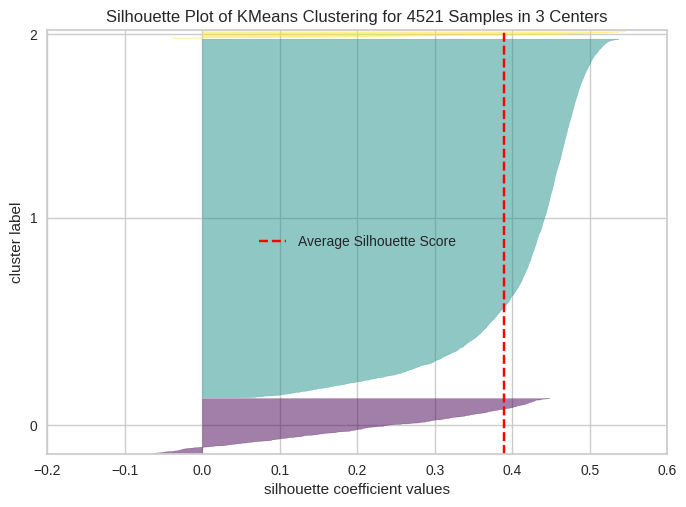

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4521 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# ----------------------------------------------------
# Visualizar la Puntuación de la Silueta
# ----------------------------------------------------


print("\nGenerando el gráfico de Silueta...")

# Crea el visualizador de silueta
visualizer = SilhouetteVisualizer(kmeans3, colors='viridis')

visualizer.fit(df_Rob)    # Entrena el visualizador con los datos escalados
visualizer.show()       # Muestra el gráfico

In [ ]:
# ----------------------------------------------------
# Analizar la distribución de la Puntuación de la Silueta por Clúster
# ----------------------------------------------------

# Obtener la puntuación de silueta para cada punto individual
sample_silhouette_values = silhouette_samples(df_Rob, y_kmeans3)

# Puntuación de la silueta promedio para todo el dataset
average_silhouette_score = silhouette_score(df_Rob, y_kmeans3)

# Contar cuántos puntos están por debajo, igual o por encima del promedio
below_average = (sample_silhouette_values < average_silhouette_score).sum()
equal_average = (sample_silhouette_values == average_silhouette_score).sum()
above_average = (sample_silhouette_values > average_silhouette_score).sum()

total_samples = len(df_Rob)

print("\n--- Análisis de la distribución de la Silueta ---")
print(f"Puntuación promedio de la Silueta: {average_silhouette_score:.4f}")
print("-" * 50)
print(f"Puntos por debajo del promedio: {below_average} ({below_average/total_samples*100:.2f}%)")
print(f"Puntos igual al promedio: {equal_average} ({equal_average/total_samples*100:.2f}%)")
print(f"Puntos por encima del promedio: {above_average} ({above_average/total_samples*100:.2f}%)")

# Obtener la puntuación de silueta para cada punto individual
sample_silhouette_values = silhouette_samples(df_Rob, y_kmeans3)

# Puntuación de la silueta promedio para todo el dataset
average_silhouette_score = silhouette_score(df_Rob, y_kmeans3)

# Agregar las puntuaciones de silueta individuales al DataFrame
mkt1['silhouette_score'] = sample_silhouette_values

#print("\n--- Análisis de la distribución de la Silueta por Clúster ---")
#print(f"Puntuación promedio de la Silueta para toda la muestra: {average_silhouette_score:.4f}")
#print("-" * 70)

# Agrupar por clúster y calcular estadísticas descriptivas
silhouette_summary = mkt1.groupby('cluster')['silhouette_score'].agg(['mean', 'min', 'max'])
print(silhouette_summary)

print("-" * 70)

# Crear una tabla de contingencia para la distribución de silueta
# Asignamos una etiqueta a cada punto: 'Por debajo', 'Igual' o 'Por encima'
mkt1['silhouette_category'] = pd.cut(mkt1['silhouette_score'],
                                   bins=[-1, average_silhouette_score, 1],
                                   labels=['Por Debajo o Igual', 'Por Encima'])

# Analizar la distribución de categorías por clúster
cluster_distribution = pd.crosstab(mkt1['cluster'], mkt1['silhouette_category'], normalize='index') * 100

print("Distribución de la Puntuación de Silueta por Clúster (%):")
print(cluster_distribution)


--- Análisis de la distribución de la Silueta ---
Puntuación promedio de la Silueta: 0.3891
--------------------------------------------------
Puntos por debajo del promedio: 1481 (32.76%)
Puntos igual al promedio: 0 (0.00%)
Puntos por encima del promedio: 3040 (67.24%)
             mean       min       max
cluster                              
0        0.222999 -0.064699  0.447770
1        0.415067  0.047445  0.536953
2        0.356868 -0.039763  0.545959
----------------------------------------------------------------------
Distribución de la Puntuación de Silueta por Clúster (%):
silhouette_category  Por Debajo o Igual  Por Encima
cluster                                            
0                             80.814941   19.185059
1                             25.194200   74.805800
2                             45.714286   54.285714


# Extra: Reducir dimensionalidad con PCA

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA a df_Rob
pca = PCA(n_components=0.83)  # Mantener 95% de varianza
df_pca = pca.fit_transform(df_Rob)

print(f"Dimensiones originales: {df_Rob.shape[1]}")
print(f"Dimensiones después de PCA: {df_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.3f}")


Dimensiones originales: 21
Dimensiones después de PCA: 7
Varianza explicada: 0.904


K=2, Silhouette Score: 0.6729
K=3, Silhouette Score: 0.1743
K=4, Silhouette Score: 0.2057
K=5, Silhouette Score: 0.2074
K=6, Silhouette Score: 0.2078
K=7, Silhouette Score: 0.2068
K=8, Silhouette Score: 0.2028
K=9, Silhouette Score: 0.1985
K=10, Silhouette Score: 0.2007
K=11, Silhouette Score: 0.1984
K=12, Silhouette Score: 0.1952
K=13, Silhouette Score: 0.1977
K=14, Silhouette Score: 0.2082
K=15, Silhouette Score: 0.2091
K=16, Silhouette Score: 0.2080
K=17, Silhouette Score: 0.2105
K=18, Silhouette Score: 0.2053
K=19, Silhouette Score: 0.2060
K=20, Silhouette Score: 0.2075
K=21, Silhouette Score: 0.2107
K=22, Silhouette Score: 0.2163
K=23, Silhouette Score: 0.2158


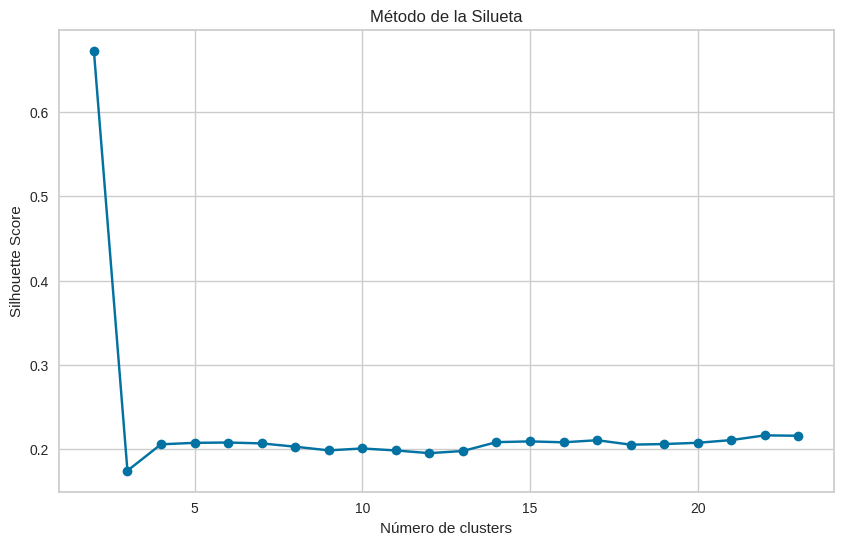

In [ ]:
# Calcular scores de silueta para diferentes k
silhouette_scores = []
for k in range(2, 24):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(range(2, 24), silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta')
plt.grid(True)
plt.show()

Aumenta tan solo un poco la metrica de K = 2 y disminuye bastante K = 3, con lo cual apreciamos que no seria de mucha ayuda implementar en este caso PCA para disminuir la dimensionalidad.